In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()
data = pd.DataFrame(california.data,columns=california.feature_names)

In [3]:
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
data['MedHouseVal'] = california.target

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


In [7]:
data.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

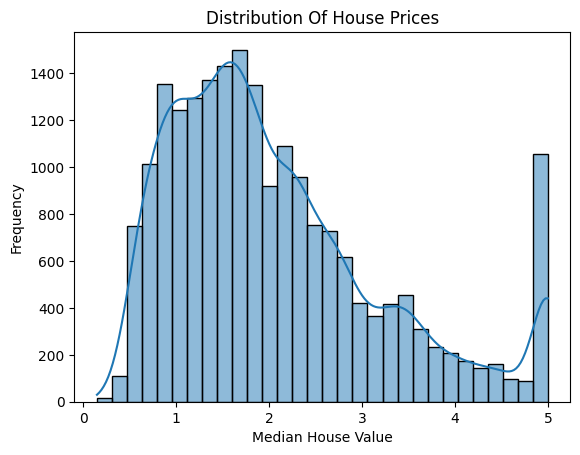

In [8]:
#EDA
sns.histplot(data['MedHouseVal'],bins=30,kde=True)
plt.title("Distribution Of House Prices")
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

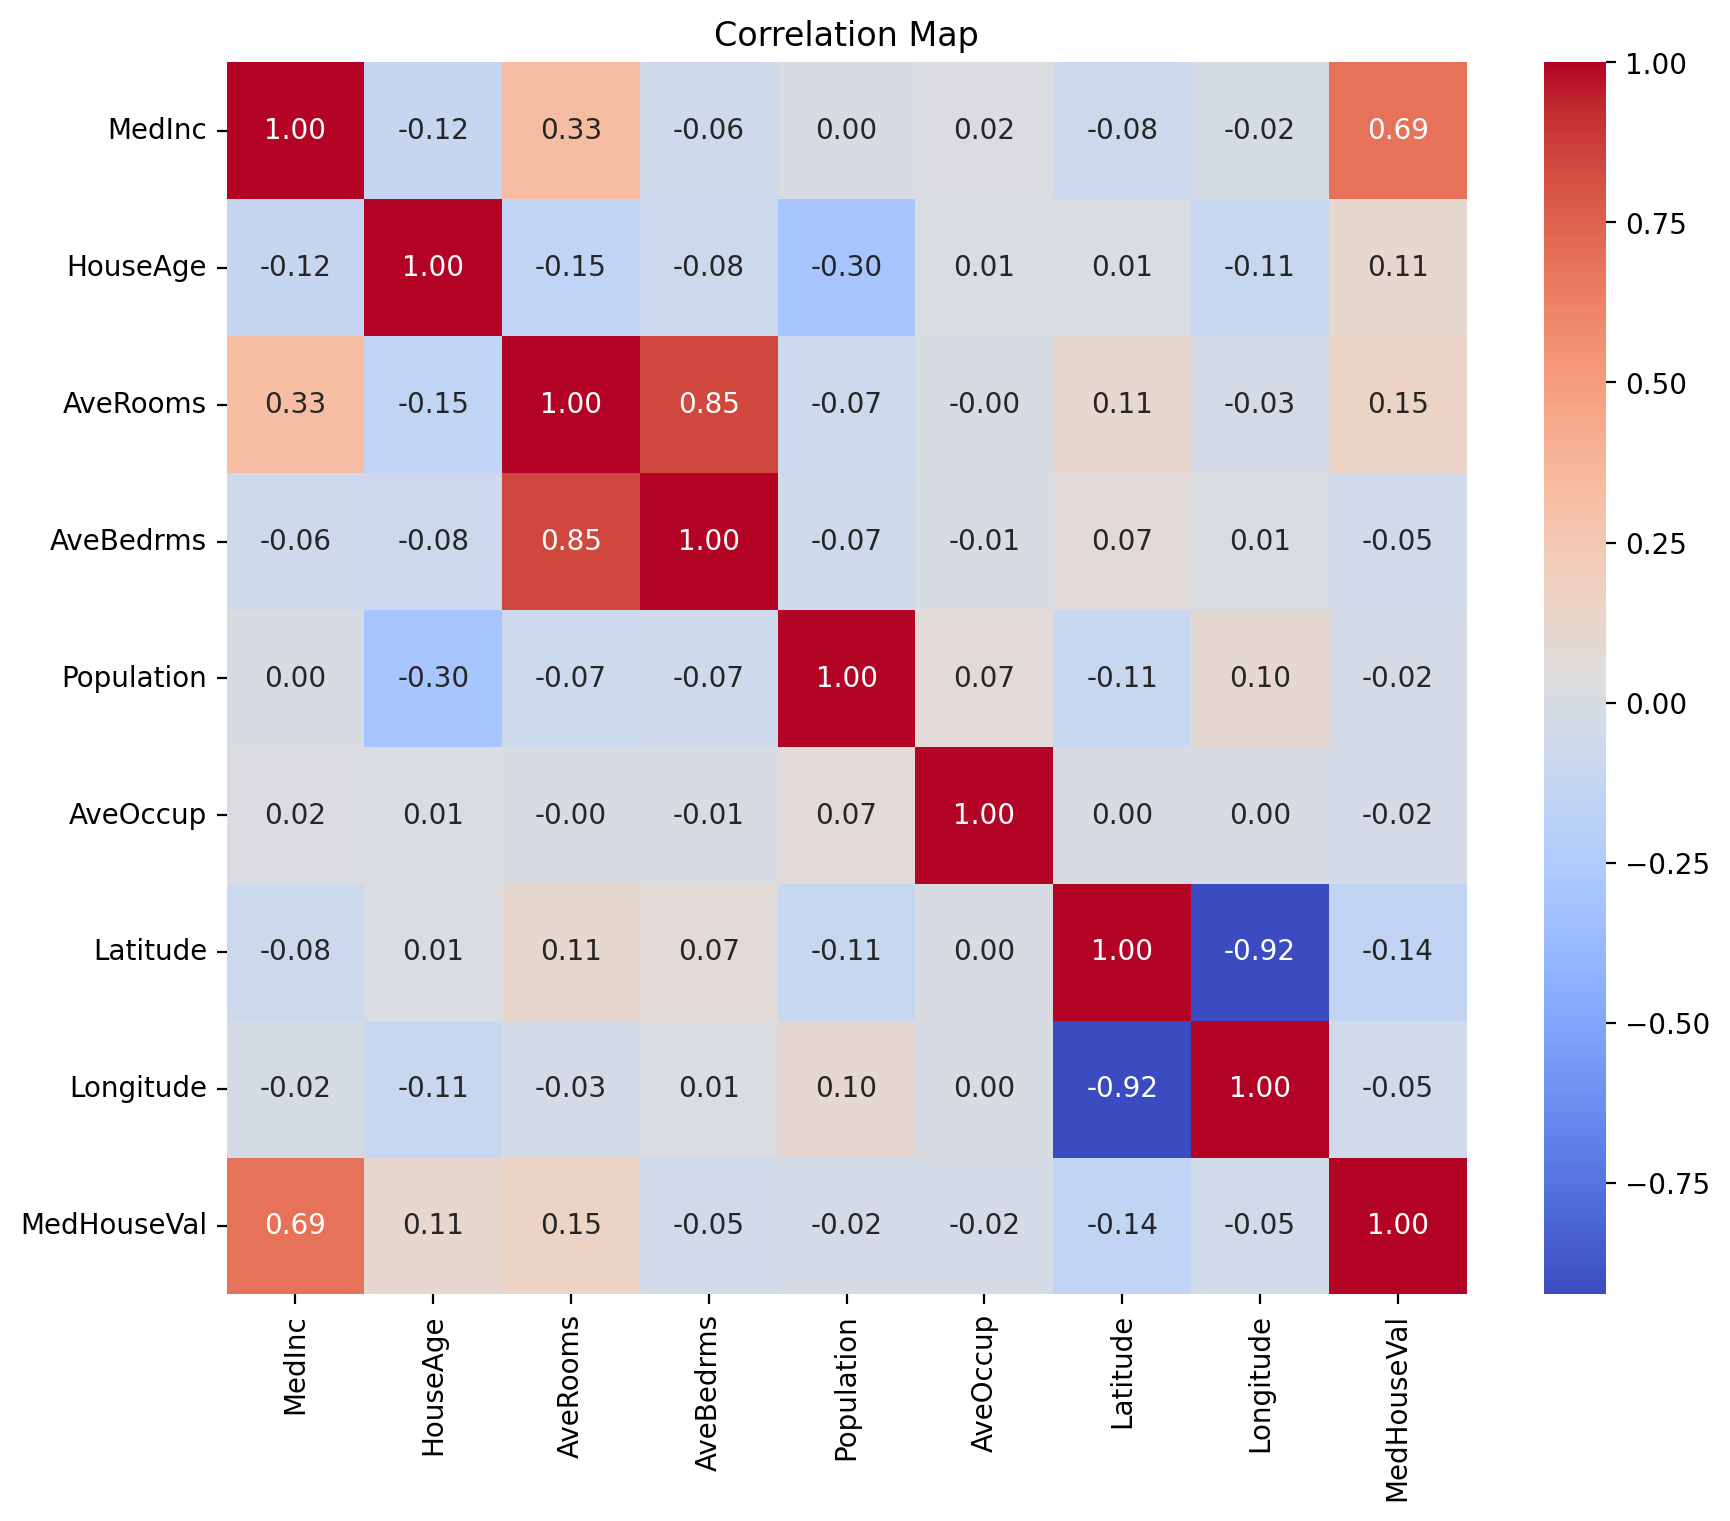

In [9]:
plt.figure(figsize=(10,8),dpi=200)
sns.heatmap(data.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Map")
plt.show()

In [10]:
#data Preprocessing
X = data.drop(columns=['MedHouseVal'])
y = data['MedHouseVal']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train , X_test , y_train , y_test = train_test_split(X ,y , test_size=0.2 , random_state=42)

In [13]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [14]:
from sklearn.linear_model import LinearRegression , Ridge , Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


In [15]:
#start for the models
models = {
    'LinearRegression' : LinearRegression(),
    'Ridge Regression' : Ridge(alpha=1.0),
    'lasso Regression' : Lasso(alpha=0.1),
    'Decision Tree' : DecisionTreeRegressor(max_depth=5),
    'Random Forest' : RandomForestRegressor(n_estimators=100),
}

In [16]:
from sklearn.metrics import mean_squared_error , mean_absolute_error , r2_score

In [17]:
results = [] # To store evaluation metrics for each model
for model_name, model in models.items():
    model.fit(X_train, y_train) # Train the model using training data
    y_pred = model.predict(X_test)
    # Evaluate model performance
    mse = mean_squared_error(y_test, y_pred) # Mean Squared Error
    mae = mean_absolute_error(y_test, y_pred) # Mean Absolute Error
    r2 = r2_score(y_test, y_pred) # R² Score (how well model explains 
    # Save results in list
    results.append({
    'Model': model_name,
    'MSE': mse,
    'MAE': mae,
    'R2 Score': r2
    })
# Convert results to a DataFrame for better visualization
results_df = pd.DataFrame(results)
print(results_df)


              Model       MSE       MAE  R2 Score
0  LinearRegression  0.555892  0.533200  0.575788
1  Ridge Regression  0.555855  0.533193  0.575816
2  lasso Regression  0.679629  0.622201  0.481361
3     Decision Tree  0.524515  0.522259  0.599732
4     Random Forest  0.251988  0.326151  0.807703


In [18]:
import pickle
# Step 1: Define and Train the Best Model
# Using Random Forest as the best model based on previous evaluation
best_model = RandomForestRegressor(n_estimators=100) 
# Train the model on the training dataset
best_model.fit(X_train, y_train) 
# Step 2: Save the Trained Model to a Pickle File
with open('best_model.pkl', 'wb') as model_file:
 # Save the trained model for future use (deployment or inferencing)
 pickle.dump(best_model, model_file) 
# Step 3: Save the Scaler Used During Preprocessing
with open('scaler.pkl', 'wb') as scaler_file:
 # Save the scaler to ensure consistent feature scaling during prediction
 pickle.dump(scaler, scaler_file)

In [21]:
import pickle

# Load the trained model and scaler
with open('best_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

with open('scaler.pkl', 'rb') as scaler_file:
    loaded_scaler = pickle.load(scaler_file)

# Define the inference function
def predict_house_price(features):
    """
    Predict the median house value for California housing data.
    
    Args:
    features (dict): A dictionary containing the following keys:
        - 'MedInc': Median income in block group
        - 'HouseAge': Median house age in block group
        - 'AveRooms': Average number of rooms per household
        - 'AveBedrms': Average number of bedrooms per household
        - 'Population': Block group population
        - 'AveOccup': Average number of household members
        - 'Latitude': Block group latitude
        - 'Longitude': Block group longitude
    
    Returns:
    float: Predicted median house value in hundreds of thousands of dollars
    """
    # Convert dictionary to DataFrame to maintain feature names
    feature_df = pd.DataFrame([features])
    
    # Scale the features
    scaled_features = loaded_scaler.transform(feature_df)
    
    # Make prediction
    prediction = loaded_model.predict(scaled_features)
    
    return prediction[0]

# Example usage
example_features = {
    'MedInc': 8.3252,
    'HouseAge': 41.0,
    'AveRooms': 6.984127,
    'AveBedrms': 1.023810,
    'Population': 322.0,
    'AveOccup': 2.555556,
    'Latitude': 37.88,
    'Longitude': -122.23
}

predicted_price = predict_house_price(example_features)
print(f"Predicted median house value: ${predicted_price * 100000:.2f}")

Predicted median house value: $432483.34
